# 01_preprocessing.ipynb
## 財務データの前処理（cleaning & transformation）

このノートブックでは、クラスタリングおよび要因分析で使用する
日本企業の財務データに対して、以下の前処理を行う。

### 🎯 目的
- 元データの構造を理解する
- 必要な変数の確認
- 欠損値の確認
- 自己資本比率の異常値検出
- 対数変換（log1p と signed_log1p）の適用対象を決定
- `cleaned_data.csv` の作成

### 📦 出力
- `data/interim/cleaned_data.csv`

このノートの内容は後で `src/preprocessing.py` としてモジュール化する。


In [1]:
# ライブラリの読み込み

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

plt.rcParams['font.family'] = 'Hiragino Sans'
plt.rcParams['axes.unicode_minus'] = False

RAW_PATH = Path("../data/raw/financial_data_clean.csv")


In [2]:
# データの読み込み
df = pd.read_csv(RAW_PATH)
df.shape

(54278, 37)

In [4]:
# データの確認
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54278 entries, 0 to 54277
Data columns (total 37 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   コード       54278 non-null  int64  
 1   総資産       53870 non-null  float64
 2   純資産       54168 non-null  float64
 3   株主資本      51948 non-null  float64
 4   利益剰余金     51366 non-null  float64
 5   短期借入金     32838 non-null  float64
 6   長期借入金     34950 non-null  float64
 7   BPS       51931 non-null  float64
 8   自己資本比率    53830 non-null  float64
 9   営業CF      51930 non-null  float64
 10  投資CF      51890 non-null  float64
 11  財務CF      51663 non-null  float64
 12  設備投資      48018 non-null  float64
 13  現金同等物     52769 non-null  float64
 14  営業CFマージン  51881 non-null  float64
 15  年度        54278 non-null  int64  
 16  売上高       54167 non-null  float64
 17  営業利益      50468 non-null  float64
 18  経常利益      51012 non-null  float64
 19  純利益       54270 non-null  float64
 20  EPS       54239 non-null  fl

In [5]:
# 欠損値の確認
df.isnull().sum().sort_values(ascending=False)

自社株買い       23844
短期借入金       21440
長期借入金       19328
純資産配当率      18528
総還元性向       17903
配当性向        15518
剰余金の配当      11885
一株配当        11027
ROE          9425
ROA          8082
設備投資         6260
営業利益         3810
経常利益         3266
利益剰余金        2912
財務CF         2615
営業CFマージン     2397
投資CF         2388
営業CF         2348
BPS          2347
株主資本         2330
現金同等物        1509
自己資本比率        448
総資産           408
売上高           111
純資産           110
EPS            39
純利益             8
17業種区分          0
規模コード           0
33業種区分          0
17業種コード         0
コード             0
33業種コード         0
市場・商品区分         0
銘柄名             0
年度              0
規模区分            0
dtype: int64

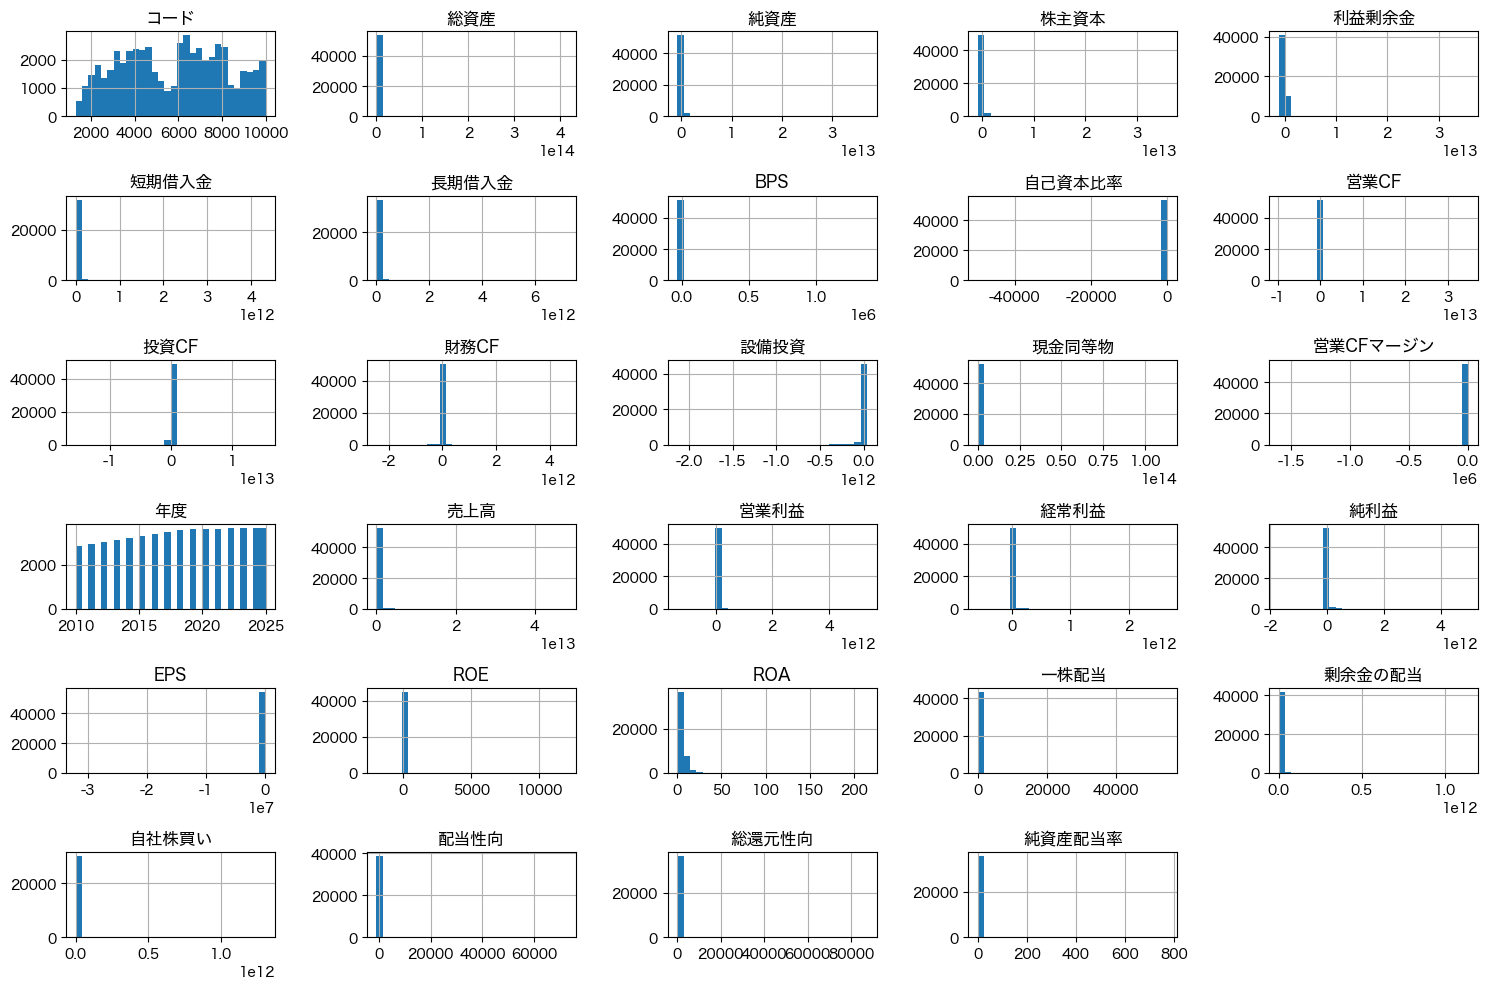

In [6]:
# 分布の確認
numeric_cols = df.select_dtypes(include=[np.number]).columns

df[numeric_cols].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()

## 研究で使用する変数の選定

今回の修士論文研究では、企業の財務構造と動態を分析するために、
財務データから以下の変数を使用する。

### 変数一覧（クラスタリング・遷移分析で使用）
- 総資産（log1p）
- 売上高（log1p）
- 自己資本比率
- 短期借入金（log1p）
- 長期借入金（log1p）
- 利益剰余金（log1p）
- 現金同等物（log1p）
- 営業利益（log1p）
- 営業CF（signed_log1p）
- 投資CF（signed_log1p）
- 財務CF（signed_log1p）

### ID・時系列管理用
- 企業コード
- 年度

これら以外の列は、本研究のクラスタリングおよび遷移分析では使用しないため除外する。

In [7]:
# 使用する変数一覧
selected_columns = [
    "コード", "年度","銘柄名",
    "総資産", "売上高", "自己資本比率",
    "短期借入金", "長期借入金",
    "利益剰余金", "現金同等物", "営業利益",
    "営業CF", "投資CF", "財務CF"
]

df_selected = df[selected_columns].copy()
df_selected.head()


,コード,年度,銘柄名,総資産,売上高,自己資本比率,短期借入金,長期借入金,利益剰余金,現金同等物,営業利益,営業CF,投資CF,財務CF
0,1301,2010,極洋,6.430100e+10,1.457780e+11,28.1,2.672400e+10,2.712000e+09,1.258900e+10,2.672000e+09,2.180000e+09,2.326000e+09,-4.515000e+09,1.142000e+09
1,1332,2010,ニッスイ,3.839240e+11,4.815740e+11,16.0,1.146390e+11,1.069930e+11,3.253000e+10,2.095200e+10,6.227000e+09,3.355000e+10,-2.877100e+10,-1.568100e+10
2,1333,2010,マルハニチロ,1.136840e+11,1.749070e+11,21.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1375,2010,ユキグニファクトリー,3.208300e+10,2.614000e+10,19.0,NaN,7.786000e+09,3.056000e+09,1.969000e+09,2.701000e+09,3.434000e+09,-9.790000e+08,-1.597000e+09
4,1376,2010,カネコ種苗,3.698258e+10,4.599569e+10,29.6,NaN,NaN,7.681619e+09,2.352426e+09,1.613650e+09,2.376787e+09,5.599700e+07,-1.082478e+09


## 7. 財務データの変数の性質と変換が必要な理由

クラスタリングは距離ベースのアルゴリズム（KMeans）を用いるため  
**スケールの大きい変数や、分布が歪んだ変数が結果に大きく影響を与える。**

そのため、各財務指標について以下の理由で log1p または signed_log1p を適用する。

### ● log1p（対数変換）を適用する理由
該当変数：総資産、売上高、短期借入金、長期借入金、利益剰余金、現金同等物、営業利益

1. いずれも右裾が長い分布（heavy-tailed）
2. 大企業と小企業のスケール差が極端である
3. クラスタリングで大企業だけが強く影響するのを防ぎたい
4. 対数変換により「相対的な差」を扱いやすくなる

### ● signed_log1p を適用する理由
該当：営業CF、投資CF、財務CF

1. CF にはマイナス値が含まれる（投資CFは特に強い）
2. log1p は負の値には適用できない（NaNになる）
3. 符号を保持することで財務行動（投資・回収・借入）の方向性を失わない

### ● 自己資本比率は変換しない理由
- すでに **比率（割合）でスケールが揃っている**
- 分布が極端に歪んでいない
- 財務健全性を示す重要指標として “そのまま” 使用する方が解釈しやすい

---

## 8. 外れ値確認（log 変換の必要性の裏付け）

ここでは各変数について、
- 分布の歪み
- 外れ値（統計的定義による範囲外）
を確認する。


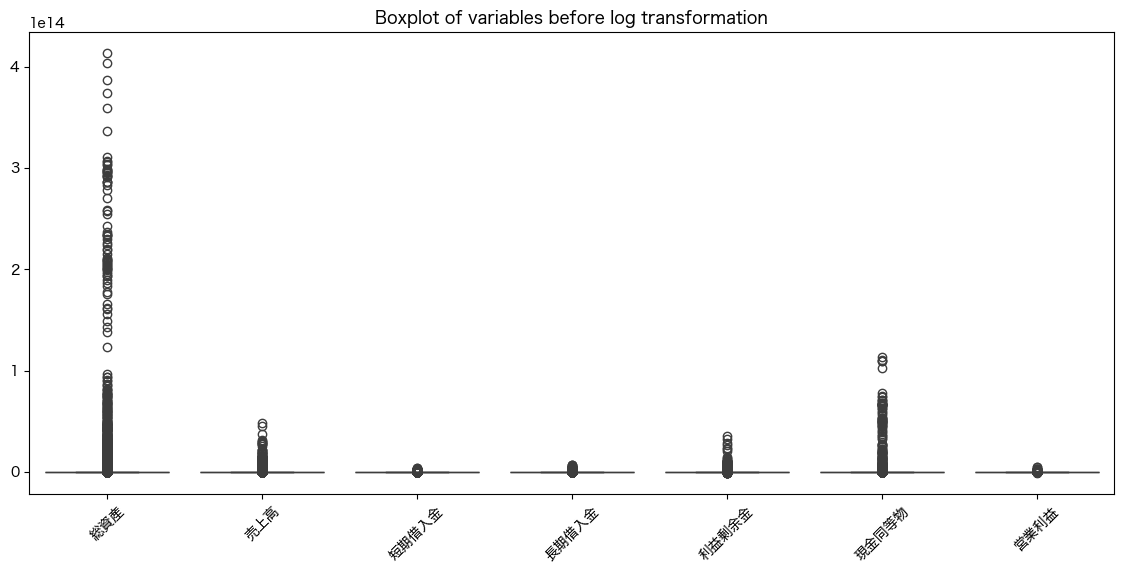

In [8]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_selected[[
    "総資産","売上高","短期借入金","長期借入金",
    "利益剰余金","現金同等物","営業利益"
]])
plt.xticks(rotation=45)
plt.title("Boxplot of variables before log transformation")
plt.show()


In [9]:
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((series < lower) | (series > upper)).sum()
    return outliers, lower, upper

for col in [
    "総資産","売上高","短期借入金","長期借入金",
    "利益剰余金","現金同等物","営業利益",
    "営業CF", "投資CF", "財務CF"
]:
    outliers, low, high = detect_outliers_iqr(df_selected[col])
    print(f"{col}: 外れ値数={outliers}, IQR下限={low:.1f}, 上限={high:.1f}")


総資産: 外れ値数=8243, IQR下限=-145559445125.0, 上限=263101581875.0
売上高: 外れ値数=7642, IQR下限=-125592460000.0, 上限=228672276000.0
短期借入金: 外れ値数=4586, IQR下限=-10918625000.0, 上限=19664375000.0
長期借入金: 外れ値数=5235, IQR下限=-14118917500.0, 上限=24844950500.0
利益剰余金: 外れ値数=7281, IQR下限=-50612602625.0, 上限=88908776375.0
現金同等物: 外れ値数=7434, IQR下限=-22793375000.0, 上限=42442425000.0
営業利益: 外れ値数=7553, IQR下限=-7315226875.0, 上限=12979536125.0
営業CF: 外れ値数=8822, IQR下限=-9240729375.0, 上限=16093637625.0
投資CF: 外れ値数=9136, IQR下限=-9071370500.0, 上限=5287617500.0
財務CF: 外れ値数=11609, IQR下限=-4900092250.0, 上限=3113461750.0


## 外れ値分布と対数変換の必要性の検証

IQR を用いて外れ値を検出したところ、総資産・売上高・利益剰余金などの主要財務変数で
数千件規模の外れ値が確認された。  
これは、日本企業の財務データが典型的な heavy-tailed distribution（右裾が長い分布）を
示しているためである。

また、営業CF・投資CF・財務CF では符号付きで大きく値が振れており、分布が左右非対称かつ
極端に広い。このため通常の log 変換が適用できず、符号を保持した signed_log1p が必要である。

以上の分析より、本研究では以下の変換を適用する。

- 総資産・売上高など規模に関する変数 → log1p（スケール圧縮・右裾の軽減）
- 営業CF・投資CF・財務CF → signed_log1p（符号保持 + スケール縮小）
- 自己資本比率 → そのまま使用（割合であり分布が極端に歪んでいない）

これにより、クラスタリングにおいて特定の変数が極端に影響力を持つことを防ぎ、
企業間比較の妥当性を確保する。


In [13]:
def signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))

log_cols = [
    "総資産","売上高","短期借入金","長期借入金",
    "利益剰余金","現金同等物","営業利益"
]

cf_cols = ["営業CF", "投資CF", "財務CF"]

df_clean = df_selected.copy()

# 異常値除外（自己資本比率 < -200）
df_clean = df_clean[df_clean["自己資本比率"] >= -200]

# log1p
for col in log_cols:
    df_clean[col + "_log"] = np.log1p(df_clean[col])

# signed_log1p
for col in cf_cols:
    df_clean[col + "_log"] = signed_log1p(df_clean[col])

# 変換後に使用する列だけ
key_cols = ["コード", "年度", "銘柄名"]
cluster_features_transformed = [c + "_log" for c in log_cols + cf_cols] + ["自己資本比率"]

df_clean = df_clean[key_cols + cluster_features_transformed]

df_clean.head()


/Users/furuken/.pyenv/versions/3.11.9/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/furuken/.pyenv/versions/3.11.9/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/furuken/.pyenv/versions/3.11.9/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


,コード,年度,銘柄名,総資産_log,売上高_log,短期借入金_log,長期借入金_log,利益剰余金_log,現金同等物_log,営業利益_log,営業CF_log,投資CF_log,財務CF_log,自己資本比率
0,1301,2010,極洋,24.886841,25.705351,24.008828,21.720952,23.256089,21.706093,21.502591,21.567416,-22.230671,20.856047,28.1
1,1332,2010,ニッスイ,26.673710,26.900326,25.465054,25.396029,24.205429,23.765500,22.552161,24.236303,-24.082634,-23.475716,16.0
2,1333,2010,マルハニチロ,25.456689,25.887520,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.5
3,1375,2010,ユキグニファクトリー,24.191592,23.986733,NaN,22.775593,21.840373,21.400792,21.716888,21.956992,-20.702042,-21.191393,19.0
4,1376,2010,カネコ種苗,24.333713,24.551813,NaN,NaN,22.762096,21.578713,21.201765,21.589015,17.840809,-20.802519,29.6


In [14]:
# 変換後の数値列（欠損があるとクラスタリング不可）
clean_columns = cluster_features_transformed

# 欠損を含む行を除外
df_clean = df_clean.dropna(subset=clean_columns)

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24309 entries, 0 to 54277
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   コード        24309 non-null  int64  
 1   年度         24309 non-null  int64  
 2   銘柄名        24309 non-null  object 
 3   総資産_log    24309 non-null  float64
 4   売上高_log    24309 non-null  float64
 5   短期借入金_log  24309 non-null  float64
 6   長期借入金_log  24309 non-null  float64
 7   利益剰余金_log  24309 non-null  float64
 8   現金同等物_log  24309 non-null  float64
 9   営業利益_log   24309 non-null  float64
 10  営業CF_log   24309 non-null  float64
 11  投資CF_log   24309 non-null  float64
 12  財務CF_log   24309 non-null  float64
 13  自己資本比率     24309 non-null  float64
dtypes: float64(11), int64(2), object(1)
memory usage: 2.8+ MB


In [15]:
from pathlib import Path

output_path = Path("../data/interim/cleaned_data.csv")
df_clean.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: ../data/interim/cleaned_data.csv
